# Multi-Feature Clustering Demo 

**Goal:** Segment **customers** into groups based on **several** features:
- `annual_income_k` (annual income in $1000s)
- `spending_score` (1-100, how much they spend)
- `age`
- `visits_per_month`

This is a classic **customer segmentation** problem — useful for targeted marketing. Just like the simple demo, there are **no labels**; K-Means finds the groups on its own.

We will use `customer_data.csv` (make sure it's in the same folder as this notebook).

## Step 1: Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Step 2: Load the dataset

In [2]:
df = pd.read_csv('customer_data.csv')
df.head()

,customer_id,annual_income_k,spending_score,age,visits_per_month
0,1,56.8,41.7,31,10
1,2,12.7,14.1,47,0
2,3,84.6,11.3,33,2
3,4,53.3,38.7,42,4
4,5,94.1,24.5,31,5


In [3]:
df.describe()

,customer_id,annual_income_k,spending_score,age,visits_per_month
count,140.0000,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.642857,42.790714,38.871429,4.500000
std,40.5586,29.718822,25.194566,10.893099,3.299226
min,1.0000,2.300000,3.400000,18.000000,0.000000
25%,35.7500,21.950000,21.050000,30.000000,1.750000
50%,70.5000,38.300000,40.650000,40.500000,5.000000
75%,105.2500,71.825000,64.325000,48.000000,7.000000
max,140.0000,104.400000,96.600000,57.000000,11.000000


## Step 3: Select features for clustering

We drop `customer_id` since it's just an identifier, not a meaningful feature.

In [4]:
features = df[['annual_income_k', 'spending_score', 'age', 'visits_per_month']]

## Step 4: Scale the features

K-Means measures **distance** between points, so features with bigger numeric ranges (like income, 0-100+) would unfairly dominate over smaller-range features (like age or visits). We use `StandardScaler` to put every feature on the same scale before clustering — an important step whenever you cluster on multiple features.

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[ 0.34300195, -0.04344709, -0.72520154,  1.67304354],
       [-1.14623437, -1.14285489,  0.74889234, -1.36885381],
       [ 1.28179492, -1.25438902, -0.54093981, -0.76047434],
       [ 0.22480859, -0.16294794,  0.288238  , -0.15209487],
       [ 1.60260546, -0.72858529, -0.72520154,  0.15209487]])

## Step 5: Use the Elbow Method to choose k

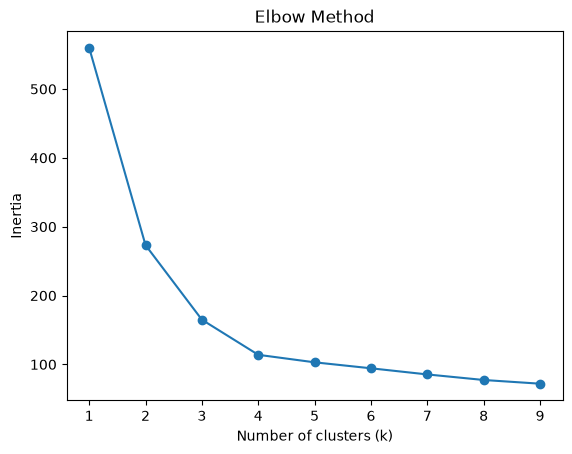

In [6]:
inertias = []
k_values = range(1, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The curve bends around **k = 4**, which matches how we built the data (4 customer groups), so we'll use that.

## Step 6: Train the K-Means model with k = 4

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)
df.head()

,customer_id,annual_income_k,spending_score,age,visits_per_month,cluster
0,1,56.8,41.7,31,10,3
1,2,12.7,14.1,47,0,1
2,3,84.6,11.3,33,2,2
3,4,53.3,38.7,42,4,3
4,5,94.1,24.5,31,5,2


## Step 7: Visualize two features at a time

With 4 features we can't plot everything at once, so we look at pairs — here income vs spending score, colored by cluster.

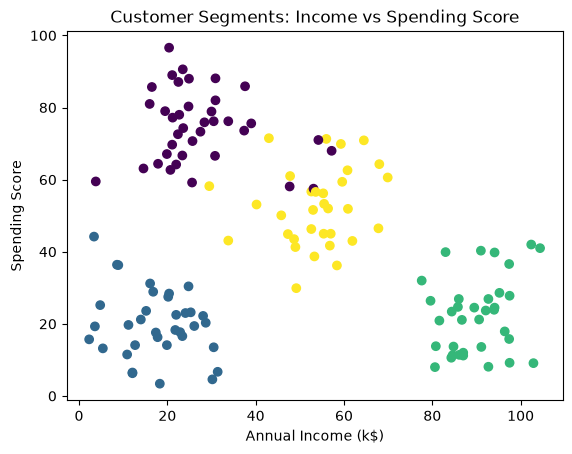

In [8]:
plt.scatter(df['annual_income_k'], df['spending_score'], c=df['cluster'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segments: Income vs Spending Score')
plt.show()

## Step 8: Profile each cluster

This is the most useful part of customer segmentation — understanding **who** is in each group so you can act on it (e.g. different marketing campaigns).

In [9]:
df['cluster'].value_counts().sort_index()

cluster
0    38
1    35
2    35
3    32
Name: count, dtype: int64

In [10]:
cluster_profile = df.groupby('cluster')[['annual_income_k', 'spending_score', 'age', 'visits_per_month']].mean().round(1)
cluster_profile

,annual_income_k,spending_score,age,visits_per_month
cluster,,,,
0,27.4,74.6,25.3,6.2
1,17.5,20.0,49.9,1.6
2,90.1,22.3,44.6,2.2
3,53.8,52.4,36.6,8.2


You can now give each cluster a business-friendly name based on its profile, e.g. "young high spenders", "wealthy low spenders", "frequent regular shoppers", etc.

## Step 9: Assign a new customer to a segment

Try changing the values below and re-running to see which segment a new customer falls into. Note we must scale the new data the same way as the training data.

In [11]:
new_customer = pd.DataFrame({
    'annual_income_k': [30],
    'spending_score': [80],
    'age': [24],
    'visits_per_month': [7]
})

new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)[0]
print(f'This customer belongs to cluster: {predicted_cluster}')

This customer belongs to cluster: 0


### Summary
- **Multi-feature clustering** = grouping data points using **several** features at once, still with no target labels.
- Because features have different scales, we used `StandardScaler` before running K-Means — always scale your features for distance-based algorithms like K-Means.
- We used the **elbow method** to pick `k = 4`, then **profiled** each cluster's average feature values to understand what each group represents.